# Predicting Gold Prices Using Past Trends (XAU/USD 2015–2026)
Anton Laitakari
## How to Run This Notebook
1. Install required libraries: `pip install pandas matplotlib seaborn scikit-learn requests`
2. Place `Gold_Data.csv` (from Kaggle) in the same folder as this notebook
3. Run all cells from top to bottom (Kernel → Restart & Run All)
4. If you don't have an internet connection for the API, uncomment the cell in the API section to load saved raw data instead

## Goal
This project investigates whether past gold price trends can be used to predict 
future gold prices. The dataset (XAU/USD daily prices, 2015–2026) is enriched with 
EUR/USD exchange rate data from the Frankfurter API to see if currency movement 
helps explain gold price changes.

## Data Sources
- Gold prices (Kaggle): https://www.kaggle.com/datasets/aminasalamt/gold-price-master-dataset-2015-2026-lxauusd
- Exchange rates (Frankfurter API): https://www.frankfurter.dev/  free, no API key required

## Data Pipeline

![pipeline](pipeline.png)

In [16]:
# This cell creates the pipeline diagram shown above and saves it as pipeline.png.
# Only needs to run once, but it's safe to re-run.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(13, 3))
ax.set_xlim(0, 11)
ax.set_ylim(0, 2)
ax.axis("off")

# Boxes for each pipeline step
steps = ["Load Gold\nCSV", "Frankfurter\nAPI (USD)", "Clean &\nMerge", "Analyze &\nVisualize", "Train\nModel", "Export\nResults"]
colors = ["#D4AF37", "#4C72B0", "#55A868", "#C44E52", "#8172B2", "#666666"]

for i, (step, color) in enumerate(zip(steps, colors)):
    x = i * 1.75 + 0.25
    ax.add_patch(mpatches.FancyBboxPatch((x, 0.5), 1.4, 1,
                 boxstyle="round,pad=0.1", color=color, alpha=0.85))
    ax.text(x + 0.7, 1.0, step, ha="center", va="center",
            fontsize=10, color="white", fontweight="bold")
    # Add an arrow between boxes
    if i < len(steps) - 1:
        ax.annotate("", xy=(x + 1.85, 1.0), xytext=(x + 1.4, 1.0),
                    arrowprops=dict(arrowstyle="->", color="black", lw=2))

plt.title("Gold Price Prediction — Data Pipeline", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("pipeline.png", dpi=150, bbox_inches="tight")
plt.close()                                             # ← close instead of show
print("Pipeline image saved as pipeline.png")

Pipeline image saved as pipeline.png


## 1. Load Gold Price Data

The Kaggle CSV has 3 header rows of metadata before the actual data starts, 
so we skip those and provide our own column names.

In [2]:
# Load the gold price dataset from Kaggle
# The CSV has 3 metadata rows at the top, so skiprows=3 skips them
import pandas as pd

df_gold = pd.read_csv(
    "Gold_Data.csv",
    skiprows=3,
    names=["date", "close", "high", "low", "open", "volume"]
)

print(f"Loaded: {df_gold.shape[0]} rows, {df_gold.shape[1]} columns")
print(f"Columns: {df_gold.columns.tolist()}")
display(df_gold.head())

Loaded: 2843 rows, 6 columns
Columns: ['date', 'close', 'high', 'low', 'open', 'volume']


,date,close,high,low,open,volume
0,2015-01-02,1186.000000,1194.500000,1169.500000,1184.000000,138
1,2015-01-05,1203.900024,1206.900024,1180.099976,1180.300049,470
2,2015-01-06,1219.300049,1220.000000,1203.500000,1203.500000,97
3,2015-01-07,1210.599976,1219.199951,1210.599976,1219.199951,29
4,2015-01-08,1208.400024,1215.699951,1206.300049,1207.000000,92


## 2. Fetch Supplementary Data from Frankfurter API

Gold is priced in USD, so the strength of the dollar likely affects its price. 
We pull EUR/USD historical rates from the free Frankfurter API to use as an 
extra feature in our analysis.

In [3]:
# Fetch EUR/USD exchange rate history from the Frankfurter API
# Free to use, no API key required
import requests

print("Fetching EUR/USD exchange rates from Frankfurter API...")

# The API returns historical daily rates for the date range we ask for
response = requests.get(
    "https://api.frankfurter.dev/v1/2015-01-01..2026-04-01",
    params={"base": "EUR", "symbols": "USD"}
)

data = response.json()

# The "rates" key holds a dict like {"2015-01-02": {"USD": 1.20}, ...}
# Convert it into a tidy DataFrame
rates_records = [
    {"date": date, "eur_usd": rate["USD"]}
    for date, rate in data["rates"].items()
]
df_fx = pd.DataFrame(rates_records)
df_fx["date"] = pd.to_datetime(df_fx["date"])
df_fx = df_fx.sort_values("date").reset_index(drop=True)

print(f"Exchange rate data: {len(df_fx)} days")
display(df_fx.head())

Fetching EUR/USD exchange rates from Frankfurter API...
Exchange rate data: 2881 days


,date,eur_usd
0,2014-12-31,1.2141
1,2015-01-02,1.2043
2,2015-01-05,1.1915
3,2015-01-06,1.1914
4,2015-01-07,1.1831


## 3. Export Raw Data

Save the raw data so a reviewer can run the rest of the notebook without 
re-fetching from the API.

In [4]:
# Export raw data so a reviewer can run without API access
df_gold.to_csv("raw_gold.csv", index=False)
df_fx.to_csv("raw_fx.csv", index=False)
print("Raw data saved to raw_gold.csv and raw_fx.csv")

# To load saved raw data instead of running the API call again, uncomment the lines below:
# df_gold = pd.read_csv("raw_gold.csv")
# df_fx = pd.read_csv("raw_fx.csv")
# df_fx["date"] = pd.to_datetime(df_fx["date"])

Raw data saved to raw_gold.csv and raw_fx.csv


## 4. Cleaning & Feature Engineering

We:
- Convert dates to proper datetime objects
- Merge the gold prices with the EUR/USD rates
- Forward-fill missing FX values (weekends/holidays have no FX data)
- Add useful features for prediction: moving averages, lagged prices, time features

In [5]:
# Make a copy so we don't modify the raw DataFrame
df = df_gold.copy()

# Make sure dates are sorted chronologically (oldest first)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

# Merge the gold prices with the EUR/USD rates on date
df_fx["date"] = pd.to_datetime(df_fx["date"])
df_merged = df.merge(df_fx, on="date", how="left")

# Weekends/holidays have no FX rate, so fill those gaps with the most recent value
df_merged["eur_usd"] = df_merged["eur_usd"].ffill()
df_merged["eur_usd"] = df_merged["eur_usd"].bfill()  # also fill any gaps at the start

# Add some time-based features
df_merged["year"] = df_merged["date"].dt.year
df_merged["month"] = df_merged["date"].dt.month
df_merged["dayofweek"] = df_merged["date"].dt.dayofweek
df_merged["day_number"] = (df_merged["date"] - df_merged["date"].min()).dt.days

# Moving averages: smooth out daily noise to see the trend
df_merged["ma_7"] = df_merged["close"].rolling(window=7).mean()
df_merged["ma_30"] = df_merged["close"].rolling(window=30).mean()

# Lag features: yesterday's price and a week ago's price (for prediction)
df_merged["lag_1"] = df_merged["close"].shift(1)
df_merged["lag_7"] = df_merged["close"].shift(7)

# The first 30 rows will have NaN values from the moving averages, so drop them
df_clean = df_merged.dropna().reset_index(drop=True)

print(f"Cleaned dataset: {df_clean.shape[0]} rows")
print(f"Date range: {df_clean['date'].min().date()} to {df_clean['date'].max().date()}")
display(df_clean.head())

Cleaned dataset: 2814 rows
Date range: 2015-02-13 to 2026-04-24


,date,close,high,low,open,volume,eur_usd,year,month,dayofweek,day_number,ma_7,ma_30,lag_1,lag_7
0,2015-02-13,1226.500000,1232.800049,1222.199951,1222.199951,65,1.1381,2015,2,4,42,1233.414289,1249.736662,1220.099976,1263.800049
1,2015-02-17,1208.099976,1234.000000,1203.000000,1227.699951,204,1.1415,2015,2,1,46,1225.714286,1250.473328,1226.500000,1262.000000
2,2015-02-18,1199.699951,1210.199951,1197.800049,1207.099976,147,1.1372,2015,2,2,47,1220.828561,1250.333325,1208.099976,1233.900024
3,2015-02-19,1207.099976,1220.000000,1205.000000,1216.500000,65,1.1387,2015,2,3,48,1216.014265,1249.926656,1199.699951,1240.800049
4,2015-02-20,1204.400024,1213.099976,1199.099976,1206.500000,51,1.1298,2015,2,4,49,1212.128557,1249.719991,1207.099976,1231.599976


In [6]:
print(df_clean.columns.tolist())

['date', 'close', 'high', 'low', 'open', 'volume', 'eur_usd', 'year', 'month', 'dayofweek', 'day_number', 'ma_7', 'ma_30', 'lag_1', 'lag_7']


## 5. Analysis & Visualization

We start by visualizing the gold price over time, then look at yearly statistics
and the correlation between gold and the dollar.

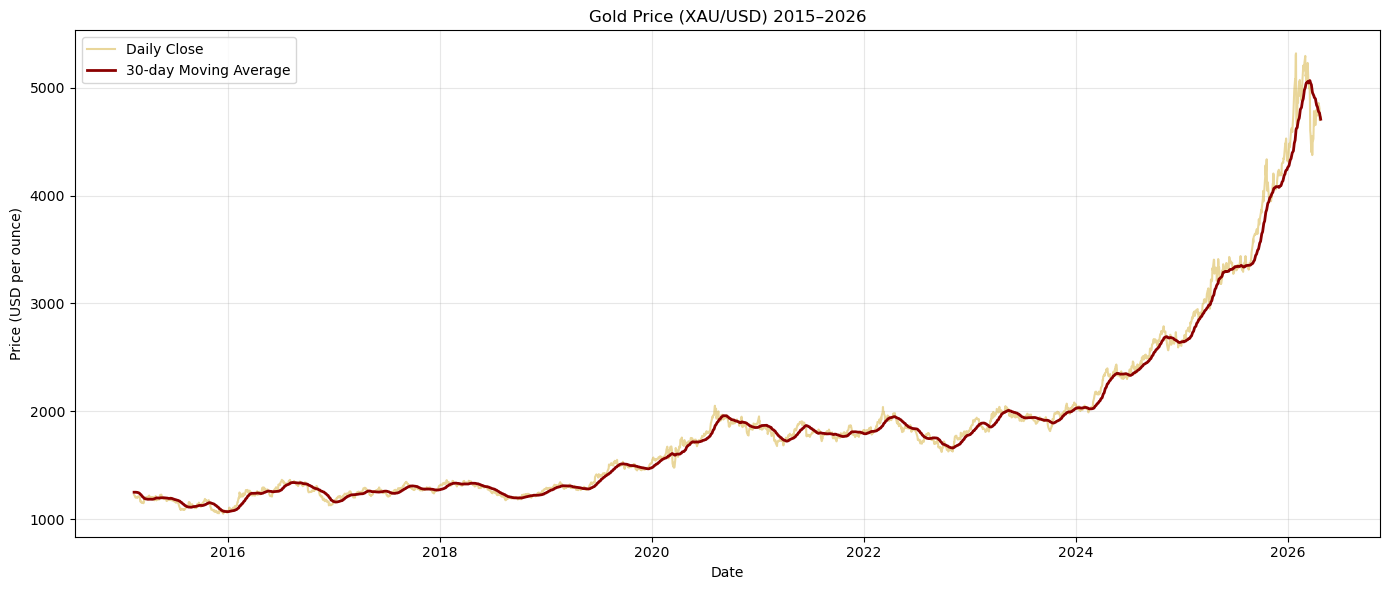

In [7]:
# Plot the full price history with the 30-day moving average
import seaborn as sns

plt.figure(figsize=(14, 6))
plt.plot(df_clean["date"], df_clean["close"],
         label="Daily Close", alpha=0.5, color="#D4AF37")
plt.plot(df_clean["date"], df_clean["ma_30"],
         label="30-day Moving Average", color="darkred", linewidth=2)
plt.title("Gold Price (XAU/USD) 2015–2026")
plt.xlabel("Date")
plt.ylabel("Price (USD per ounce)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Yearly gold price statistics:


,avg_price,volatility,min_price,max_price
year,,,,
2015,1146.92,48.02,1050.8,1227.8
2016,1249.71,72.47,1073.9,1364.9
2017,1257.70,34.20,1160.4,1346.0
2018,1267.60,54.14,1176.2,1362.4
2019,1392.72,92.91,1269.3,1550.3
2020,1773.16,139.69,1477.3,2051.5
2021,1797.67,49.32,1677.7,1952.7
2022,1800.07,92.73,1623.3,2040.1
2023,1942.77,60.08,1808.8,2081.9


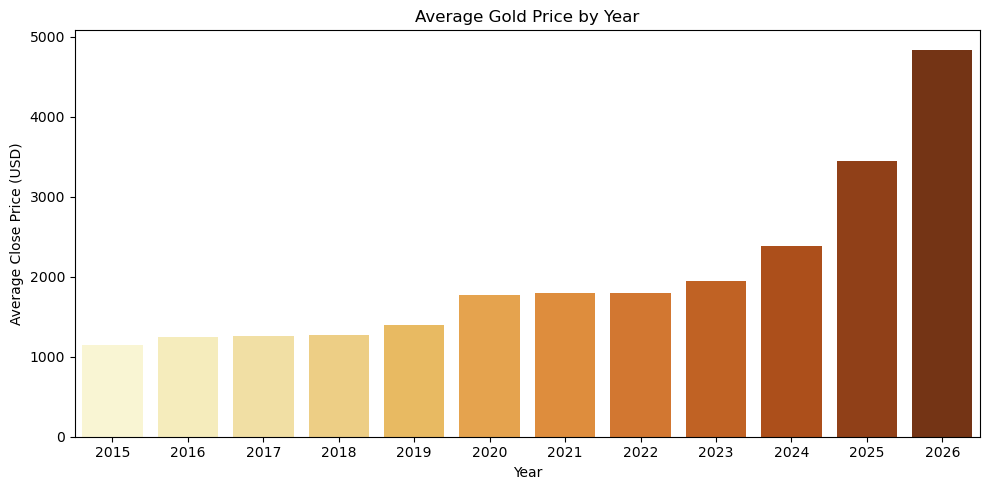

In [8]:
# Compute yearly stats: average price, volatility (std), min, max
yearly_stats = df_clean.groupby("year").agg(
    avg_price=("close", "mean"),
    volatility=("close", "std"),
    min_price=("close", "min"),
    max_price=("close", "max")
).round(2)

print("Yearly gold price statistics:")
display(yearly_stats)

# Bar plot of yearly average price
plt.figure(figsize=(10, 5))
sns.barplot(x=yearly_stats.index, y=yearly_stats["avg_price"], palette="YlOrBr")
plt.title("Average Gold Price by Year")
plt.xlabel("Year")
plt.ylabel("Average Close Price (USD)")
plt.tight_layout()
plt.show()

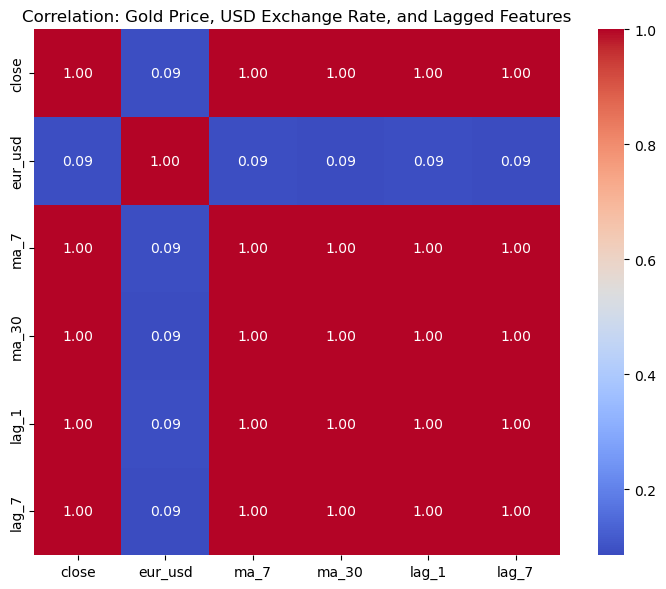

In [9]:
# Correlation matrix between gold price, FX rate, and our engineered features
factor_cols = ["close", "eur_usd", "ma_7", "ma_30", "lag_1", "lag_7"]
corr = df_clean[factor_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation: Gold Price, USD Exchange Rate, and Lagged Features")
plt.tight_layout()
plt.show()

### Monthly Volatility 

### Which Months Have the Biggest Swings?
   
   I wanted to find out which calendar months historically show the most price 
   instability. This could be useful for someone planning when to buy or sell gold.

In [10]:
# Monthly Volatility Analysis 
# which months have the biggest gold price swings?

# Step 1: Group by month and compute standard deviation of close price
monthly_volatility = df_clean.groupby("month")["close"].std()

# Step 2: Print the results, sorted from most to least volatile
print("Volatility by month:")
print(monthly_volatility.sort_values(ascending=False))

Volatility by month:
month
2     1044.688958
3     1012.975289
1      986.049885
4      953.350265
12     902.372471
10     827.745615
11     808.717841
9      716.756091
7      635.489728
8      621.284207
5      605.319294
6      602.533800
Name: close, dtype: float64


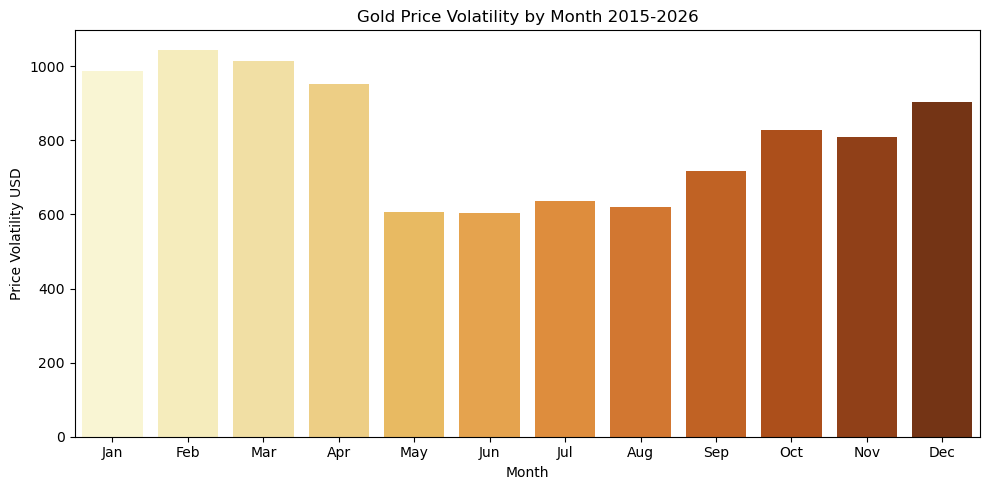

In [11]:
# Visualize: monthly volatility as a bar chart
import matplotlib.pyplot as plt
import seaborn as sns

# Use month names for nicer labels
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.figure(figsize=(10, 5))
sns.barplot(x=month_names, y=monthly_volatility.values, palette="YlOrBr")
plt.title("Gold Price Volatility by Month 2015-2026")  # ← write a clear title yourself
plt.xlabel("Month")  # ← what's on the x-axis?
plt.ylabel("Price Volatility USD")  # ← what's on the y-axis?
plt.tight_layout()
plt.show()

## What I Found

* Most volatile month: February (std 1044)
* Least volatile month: June (std 602)

The early months of the year (Jan-Apr) tend to be the most volatile, while summer (May-Aug) is the calmest. This could reflect uncertainty around new-year economic outlooks and central bank decisions in Q1, while summer is typically a slow period for financial markets. Useful to know if you're trading or buying gold.

## 6. Train a Prediction Model

We fit a linear regression to predict the gold price using:
- Yesterday's close (`lag_1`) and a week ago's close (`lag_7`)
- 7-day and 30-day moving averages (`ma_7`, `ma_30`)
- The EUR/USD exchange rate
- A linear time index

Important: we split the data **chronologically** (train on past, test on future). 
A random split would let the model "see" future data, which would be cheating for 
a forecasting task.

In [12]:
# Train a linear regression model to predict next-day gold price
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Features used for prediction
features = ["lag_1", "lag_7", "ma_7", "ma_30", "eur_usd", "day_number"]
X = df_clean[features]
y = df_clean["close"]

# Chronological split: first 80% for training, last 20% for testing
split_idx = int(len(df_clean) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_test = df_clean["date"].iloc[split_idx:]

# Train and predict
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: ${mae:.2f}")
print(f"R² Score: {r2:.3f}")
print("\nFeature coefficients (how much each feature affects the prediction):")
for feat, coef in zip(features, model.coef_):
    print(f"  {feat}: {coef:.4f}")

Mean Absolute Error: $34.76
R² Score: 0.996

Feature coefficients (how much each feature affects the prediction):
  lag_1: 0.7531
  lag_7: -0.1149
  ma_7: 0.3478
  ma_30: 0.0069
  eur_usd: 2.5842
  day_number: 0.0023


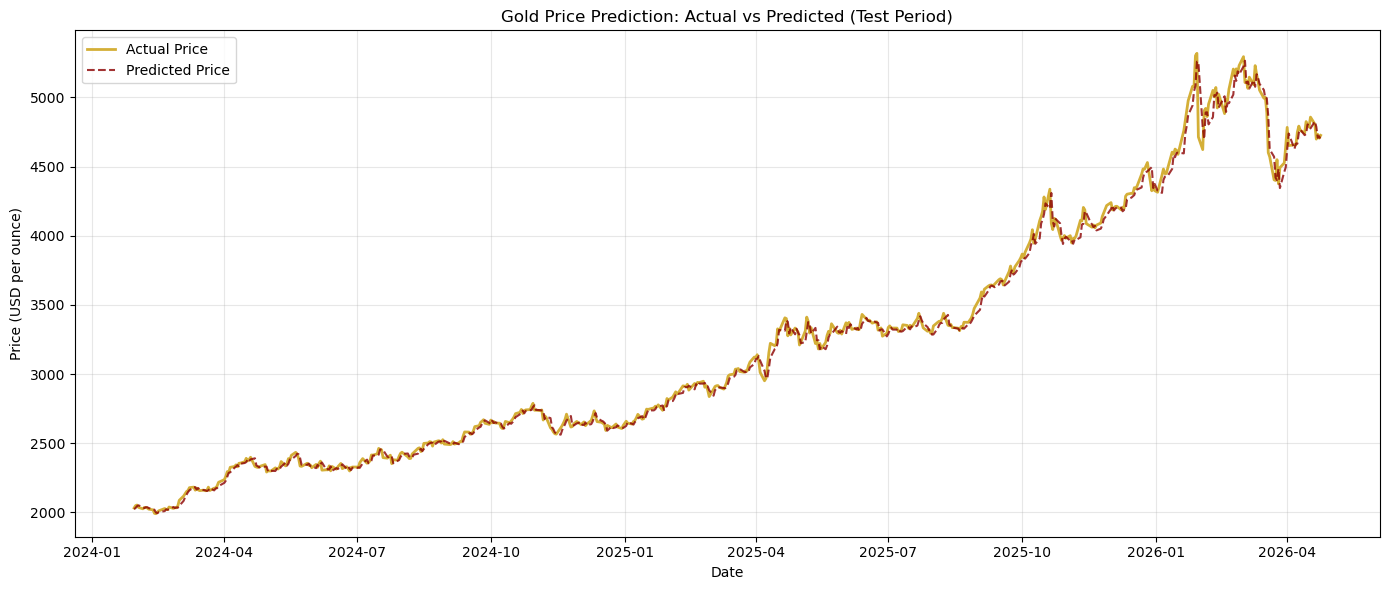

In [13]:
# Plot predictions vs actual prices over the test period
plt.figure(figsize=(14, 6))
plt.plot(dates_test, y_test.values,
         label="Actual Price", color="#D4AF37", linewidth=2)
plt.plot(dates_test, y_pred,
         label="Predicted Price", color="darkred", linestyle="--", alpha=0.8)
plt.title("Gold Price Prediction: Actual vs Predicted (Test Period)")
plt.xlabel("Date")
plt.ylabel("Price (USD per ounce)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Key Findings Summary

Print out the main numbers so we can use them in the conclusion.

In [14]:
# Summary stats for use in conclusion
overall_change = ((df_clean["close"].iloc[-1] - df_clean["close"].iloc[0])
                  / df_clean["close"].iloc[0]) * 100
most_volatile_year = yearly_stats["volatility"].idxmax()
highest_year = yearly_stats["avg_price"].idxmax()
lowest_year = yearly_stats["avg_price"].idxmin()
gold_fx_corr = df_clean["close"].corr(df_clean["eur_usd"])

print("=== KEY FINDINGS ===")
print(f"Overall price change 2015 to 2026: {overall_change:+.1f}%")
print(f"Highest avg-price year: {highest_year} (${yearly_stats.loc[highest_year, 'avg_price']:.0f})")
print(f"Lowest avg-price year: {lowest_year} (${yearly_stats.loc[lowest_year, 'avg_price']:.0f})")
print(f"Most volatile year: {most_volatile_year} (std ${yearly_stats.loc[most_volatile_year, 'volatility']:.0f})")
print(f"Correlation gold ↔ EUR/USD: {gold_fx_corr:.3f}")
print(f"Model R² on test set: {r2:.3f}")
print(f"Model average error: ${mae:.2f}")

=== KEY FINDINGS ===
Overall price change 2015 to 2026: +285.3%
Highest avg-price year: 2026 ($4838)
Lowest avg-price year: 2015 ($1147)
Most volatile year: 2025 (std $483)
Correlation gold ↔ EUR/USD: 0.090
Model R² on test set: 0.996
Model average error: $34.76


## 8. Export Results

In [15]:
# Export cleaned dataset, yearly stats, and predictions
df_clean.to_csv("cleaned_gold_data.csv", index=False)
yearly_stats.to_csv("yearly_statistics.csv")

predictions_df = pd.DataFrame({
    "date": dates_test.values,
    "actual_price": y_test.values,
    "predicted_price": y_pred
})
predictions_df.to_csv("predictions.csv", index=False)

print("Exported: cleaned_gold_data.csv, yearly_statistics.csv, predictions.csv")

Exported: cleaned_gold_data.csv, yearly_statistics.csv, predictions.csv


## Conclusion

This project investigated whether past gold price trends, combined with USD exchange rate data, can predict future gold prices.

**Key findings:**

- Gold prices increased by **+285.3%** between 2015 and 2026, nearly quadrupling in value.
- The highest average price year was **2026 (\$4,838)**, while the lowest was **2015 (\$1,147)**.
- **2025** was the most volatile year (standard deviation of \$483), likely tied to major global economic events.
- The linear regression model achieved an R² of **0.996** on the test set, with an average prediction error of **\$34.76** per ounce.
- The correlation between gold price and EUR/USD was only **0.090**, meaning the EUR/USD exchange rate has very little direct relationship with gold price.

**Interpretation:** Past prices (especially the previous day's close and the 7-day moving average) are extremely strong predictors of future gold prices. The model's R² of 0.996 indicates it explains 99.6% of the variation in gold price during the test period. This shows that gold has very strong price momentum: the best predictor of tomorrow's price is essentially today's price plus the recent trend. The EUR/USD exchange rate added almost no extra predictive power, contrary to the common belief that a weaker dollar always pushes gold higher.

**Limitations:** The model uses simple linear regression, so it can't capture non-linear patterns. More advanced models like ARIMA or LSTM neural networks might perform better at predicting larger directional changes. Also, the model relies heavily on lagged prices, meaning it can predict gradual movements well but cannot anticipate sudden price shocks caused by external events such as wars, pandemics, or central bank policy changes.

## AI Usage Statement

I used Claude (claude.ai) as a study aid throughout this project. I treated it like a tutor: when I got stuck I asked for help with a specific part, then read through the result and made sure I could explain it before moving on.

I picked the topic and found the Kaggle gold price dataset myself. Claude helped me find the Frankfurter API as a free supplementary source for EUR/USD data, structure the notebook into clear sections, debug some pandas errors during the cleaning step, and explain concepts like why we split chronologically instead of randomly for time series, and why the high R² of 0.996 is partly due to using lagged prices.

I ran every cell, looked at the actual outputs, and wrote the conclusion sections in my own words based on what the numbers showed. I also went through a comprehension walkthrough of the code with Claude.

All analysis is based on real data from the Kaggle gold price dataset and the live Frankfurter API. No values were generated by AI.